In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Helvetica Neue"

## Load data

In [16]:
dfs = []
for sample in ["sample_1_1", "sample_2_1", "sample_3_1"]:
    _df = pd.read_csv(f"{sample}.csv")
    _df["sample"] = sample
    dfs.append(_df)

df = pd.concat(dfs, ignore_index=True)
df = df[df["action"].notna() & (df["action"] != "[mistake/redundant]")]

## Define Mappings

In [17]:
action_groups = {
    # Move
    "[drag] [design object] to [new position] using [cursor]": "Drag Object",
    "[drag] [design object] to [new position] using [cursor] and [alignment grids]": "Drag Object w/ Alignment",
    "[drag] [design object] to [new position] using [cursor] and [ reference object]": "Drag Object w/ Reference",
    "[drag] [selected] to [new position] using [cursor]": "Drag Selected",
    "[move] [selected] to [new position] using [keyboard] and [alignment grids]": "Move Object w/ Keyboard",
    # Resize
    "[drag] [design object] to [resize]": "Resize Object",
    "[drag] [design object] to [resize] using [reference object]": "Resize Object w/ Reference",
    # Selection
    "[drag] to [multiselect] [design objects] on [canvas] using [cursor]": "Multiselect Objects",
    "[deep select] [design object] on [canvas] using [cursor]": "Deep Select Object",
    "[deep select] [text object] on [canvas] using [cursor]": "Deep Select Object",
    "[select] [design object] on [canvas] using [cursor]": "Select Object",
    "[hover] over [design objects] on [canvas]": "Hover Canvas Objects",
    "[hover] over [design objects] in [layers panel]": "Hover Layer Objects",
    # Navigation
    "[zoom]": "Zoom",
    "[zoom] to focus [selected]": "Zoom to Selection",
    "[zoom] to focus [design object]": "Zoom to Object",
    "[zoom] to fit context in viewport": "Zoom to Fit Context",
    "[pan]": "Pan",
    "[pan] to focus [design object]": "Pan to Object",
    "[scroll] [gui panel]": "Scroll Panel",
    # Editing
    "[update] [text object] using [keyboard]": "Edit Text",
    "[update] [text object] with [keyboard]": "Edit Text",
    "[update] [gui input] to [value]": "Update GUI Input Value",
    "[update] [design object name]": "Rename Object",
    # UI Interaction
    "[click] [gui icon]": "Click UI Icon",
    "[expand] [gui menu]": "Expand Menu",
    "[expand] [gui menu] + [click] [gui icon]": "Menu Action",
    "[scroll] [gui panel] + [expand] [gui menu] + [click gui icon]": "Panel Menu Action",
    "[expand] [gui menu] + [scroll] [gui panel] + [click gui icon]": "Panel Menu Action",
    # Creation
    "[create] [autolayout]": "Create Auto Layout",
    "[create] [alignment guide] using [reference object]": "Create Alignment Guide",
    "[create] [frame] from [selected]": "Create Frame",
    "[drag] to [create] [design object] at [new position] on [canvas] using [cursor]": "Drag to Create Object",
    # Structure
    "[duplicate] [selected]": "Duplicate Selection",
    "[ungroup] [selected] using [cursor]": "Ungroup Selection",
    "[collapse] [group] on [layers panel]": "Collapse Group",
    # System / Tools
    "[activate] [tool]": "Activate Tool",
    "[undo]": "Undo",
}

In [ ]:
# difficulty_map = {
#     "[zoom] and [pan]": "VERY HARD",
#     "[zoom]": "HARD",
#     "[zoom] to focus [design object]": "VERY HARD",
#     "[select] [design object] on [canvas] using [cursor]": "HARD",
#     "[deep select] [design object] on [canvas] using [cursor]": "VERY HARD",
#     "[deep select] [text object] on [canvas] using [cursor]": "VERY HARD",
#     "[multiselect] [design objects] on [canvas] using [cursor]": "VERY HARD",
#     "[deselect]": "EASY",
#     "[create] [text object] at [new position] on [canvas]": "HARD",
#     "[create] [design object] at [new position] on [canvas]": "HARD",
#     "[drag] to [create] [design object] at [new position] on [canvas] using [cursor]": "VERY HARD",
#     "[drag] [design object] to [new position] using [cursor]": "VERY HARD",
#     "[drag] [design object] to [new position] using [cursor] and [alignment grids]": "VERY HARD",
#     "[move] [selected] to [new position] using [keyboard] and [alignment grids]": "MEDIUM",
#     "[update] [text object] using [keyboard]": "MEDIUM",
#     "[update] [text object] with [keyboard]": "MEDIUM",
#     "[click] [gui icon]": "EASY",
#     "[update] [gui input] to [value]": "MEDIUM",
#     "[expand] [gui menu] + [click] [gui icon]": "MEDIUM",
#     "[scroll] [gui panel] + [expand] [gui menu] + [click gui icon]": "MEDIUM",
#     "[expand] [gui menu] + [scroll] [gui panel] + [click gui icon]": "MEDIUM",
#     "[expand] [gui menu]": "EASY",
#     "[scroll] [gui panel]": "MEDIUM",
#     "[activate] [tool]": "EASY",
#     "[create] [autolayout]": "MEDIUM",
#     "[duplicate] [selected]": "MEDIUM",
#     "[undo]": "EASY",
#     "[drag] [design object] to [new position] using [cursor] and [ reference object]": "VERY HARD",
#     "[drag] [design object] to [resize] using [reference object]": "VERY HARD",
#     "[create] [alignment guide] using [reference object]": "HARD",
#     "[zoom] to fit context in viewport": "HARD",
#     "[pan] to focus [design object]": "VERY HARD",
#     "[create] [frame] from [selected]": "MEDIUM",
#     "[hover] over [design objects] in [layers panel]": "EASY",
#     "[collapse] [group] on [layers panel]": "EASY",
#     "[update] [design object name]": "MEDIUM",
#     "[hover] over [design objects] on [canvas]": "EASY",
#     "[zoom] to focus [selected]": "VERY HARD",
#     "[drag] [selected] to [new position] using [cursor]": "VERY HARD",
#     "[pan]": "HARD",
#     "[drag] to [multiselect] [design objects] on [canvas] using [cursor]": "VERY HARD",
#     "[drag] [design object] to [resize] ": "VERY HARD",
#     "[ungroup] [selected] using [cursor]": "MEDIUM",
# }

## Data Preparation

In [18]:
df["start"]                    = pd.to_numeric(df["start"],                    errors="coerce")
df["end"]                      = pd.to_numeric(df["end"],                      errors="coerce")
df["duration"]                 = pd.to_numeric(df["duration"],                 errors="coerce")
df["true_duration_unlabelled"] = pd.to_numeric(df["true_duration_unlabelled"], errors="coerce")
df["estimated_duration"]       = pd.to_numeric(df["estimated_duration"],       errors="coerce")
df["tag"]                      = df["tag_primary"].str.strip()
df["how"]                      = df["how_primary"].str.strip()
df["action"]                   = df["action"].str.strip()

In [19]:
# df["difficulty"]    = df["action"].map(difficulty_map)
df["action_bundle"] = df["action"].map(action_groups)

In [20]:
df = df.drop(columns=["Title", "video", "initial_code",
                       "difficulty_with_existing_speech_tools",
                       "tag_secondary", "how_secondary", "insights_and_notes"])

In [21]:
df.head()

,sample,start,end,action,tag_primary,how_primary,location,intent,adjusted_start,adjusted_end,duration,true_duration,true_duration_unlabelled,estimated_duration,tag,how,action_bundle
0,sample_1_1,0.21,0.21,[zoom] and [pan],navigation,complex gesture,NaN,NaN,0.0,0.0,0.0,<1 second,1.0,0.5,navigation,complex gesture,NaN
1,sample_1_1,0.22,0.22,[activate] [tool],activate tool,cursor,gui,activate text tool,1.0,1.0,0.0,<1 second,1.0,0.5,activate tool,cursor,Activate Tool
2,sample_1_1,0.22,0.22,[zoom],navigation,gesture,NaN,NaN,1.0,1.0,0.0,<1 second,1.0,0.5,navigation,gesture,Zoom
3,sample_1_1,0.23,0.23,[create] [text object] at [new position] on [c...,creating text,cursor,canvas,NaN,2.0,2.0,0.0,<1 second,1.0,0.5,creating text,cursor,NaN
4,sample_1_1,0.23,0.26,[update] [text object] using [keyboard],update text object content,keyboard,canvas,NaN,2.0,5.0,3.0,<4 seconds,4.0,3.5,update text object content,keyboard,Edit Text


## Exploratory Analysis

In [22]:
df["tag_primary"].value_counts()

tag_primary
selection                        33
navigation                       29
gui interaction                  14
spatial positioning              13
resize design object             11
information revealing             5
activate tool                     4
creating design object            4
update text object content        3
create autolayout                 3
update design object property     3
grouping                          3
update text object property       2
update text object size           2
copy/paste                        2
update autolayout                 2
alignment guides                  2
undo                              2
creating text                     1
rename                            1
Name: count, dtype: int64

In [23]:
df["location"].value_counts()

location
gui             20
canvas          18
layers panel     4
Name: count, dtype: int64

In [24]:
print(df["true_duration_unlabelled"].describe())
print()
print(df["duration"].describe())

count    137.000000
mean       1.642336
std        1.096366
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        7.000000
Name: true_duration_unlabelled, dtype: float64

count    137.000000
mean       0.642336
std        1.096366
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        6.000000
Name: duration, dtype: float64


In [ ]:
# df["difficulty"].value_counts()

Some other potential considerations could be looking at dwell time and idle time.

## Visualisations

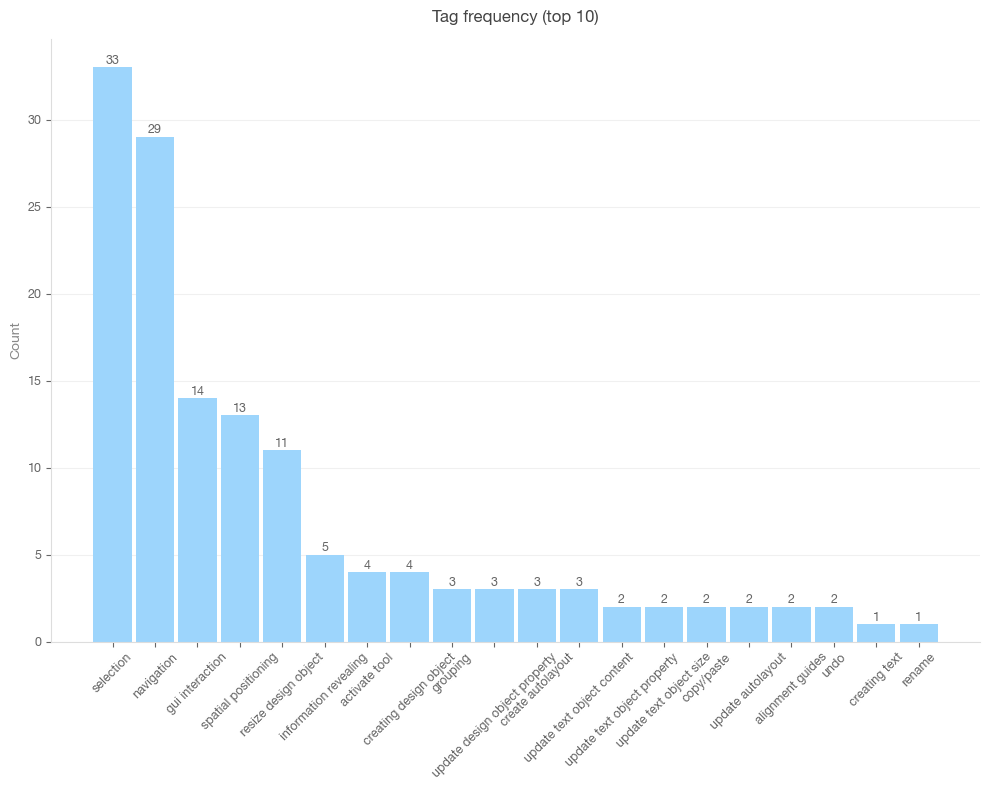

In [25]:
df_plot = df["tag_primary"].value_counts().sort_values(ascending=False).head(30)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.bar(df_plot.index, df_plot.values, color="#9DD5FC", edgecolor="none", width=0.9)

for bar, val in zip(bars, df_plot.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.2,
            str(val), ha="center", fontsize=9, color="#666")

ax.set_ylabel("Count", fontsize=10, color="#888")
ax.tick_params(axis="x", labelsize=9, colors="#666", rotation=45)
ax.tick_params(axis="y", labelsize=9, colors="#666")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#ddd")
ax.yaxis.grid(True, color="#f0f0f0", zorder=0)
ax.set_axisbelow(True)
ax.set_title("Tag frequency (top 10)", fontsize=12, color="#444", pad=12)
plt.tight_layout()
plt.show()

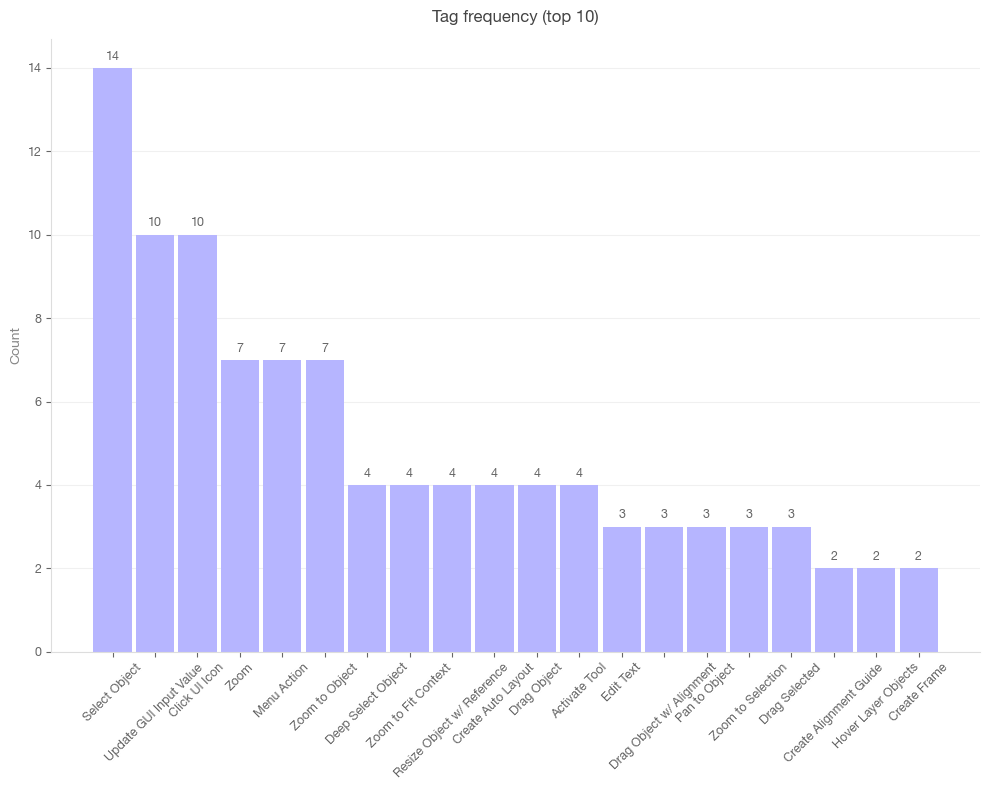

In [26]:
df_plot = df["action_bundle"].value_counts().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.bar(df_plot.index, df_plot.values, color="#B6B5FF", edgecolor="none", width=0.9)

for bar, val in zip(bars, df_plot.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.2,
            str(val), ha="center", fontsize=9, color="#666")

ax.set_ylabel("Count", fontsize=10, color="#888")
ax.tick_params(axis="x", labelsize=9, colors="#666", rotation=45)
ax.tick_params(axis="y", labelsize=9, colors="#666")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#ddd")
ax.yaxis.grid(True, color="#f0f0f0", zorder=0)
ax.set_axisbelow(True)
ax.set_title("Tag frequency (top 10)", fontsize=12, color="#444", pad=12)
plt.tight_layout()
plt.show()

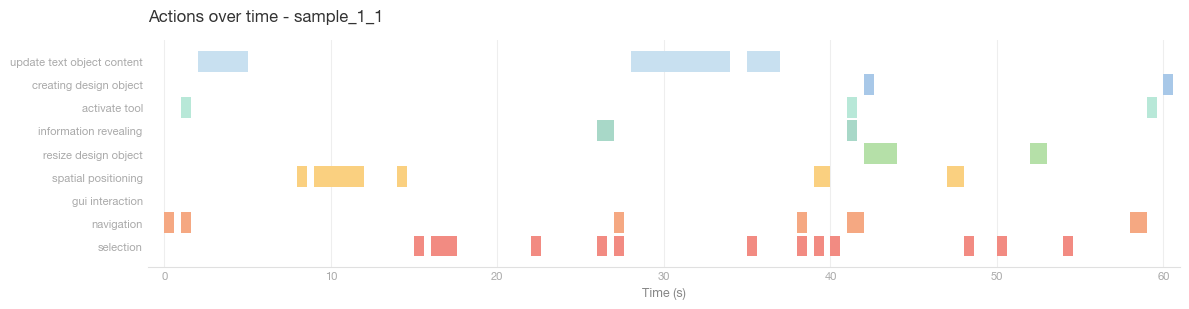

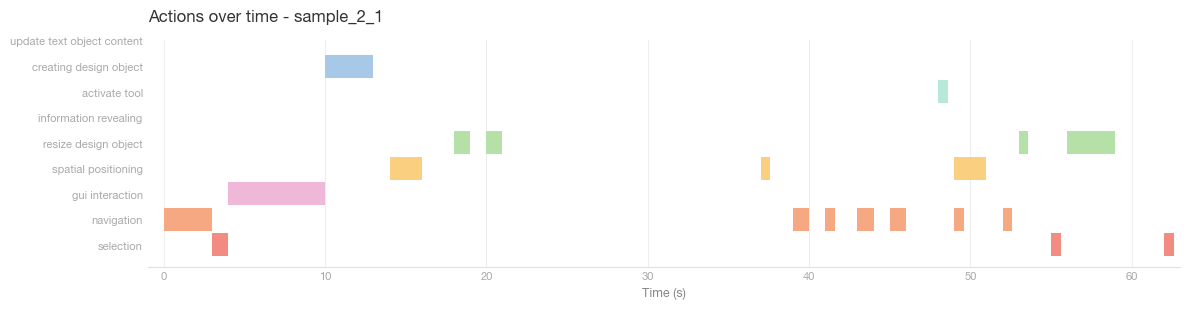

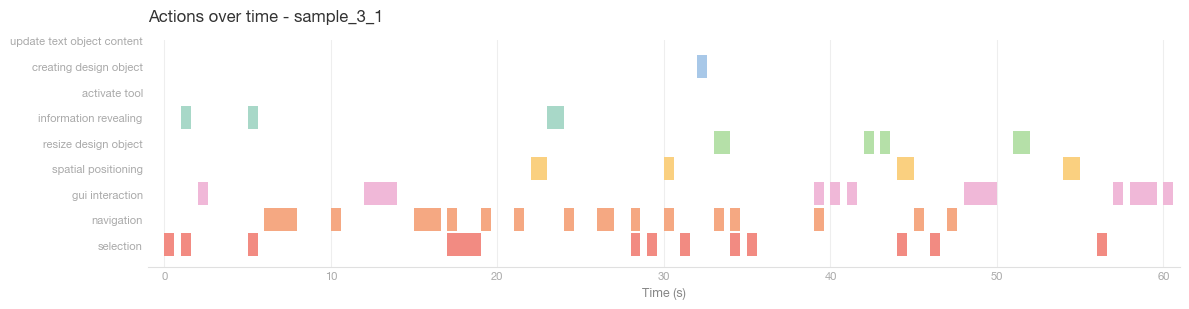

In [27]:
colors_list = [
    '#F28B82',  # soft red
    '#F5A882',  # peach coral
    '#F0B8D8',  # soft pink
    '#FAD080',  # warm yellow
    '#B5E0A8',  # sage green
    '#A8D8C8',  # mint
    '#B8E8D8',  # pale teal
    '#A8C8E8',  # steel blue
    '#C8E0F0',  # sky blue
    '#A8A8E8',  # periwinkle
    '#C8B8F0',  # soft violet
    '#E8C8F0',  # pale lilac
]


all_tags = df["tag"].value_counts().index.tolist()
global_color_map = {tag: colors_list[i % len(colors_list)] for i, tag in enumerate(all_tags)}


def plot_timeline(sample, n_tags=9, min_width=0.6, bar_height=0.9):
    top_tags = df["tag"].value_counts().head(n_tags).index.tolist()
    plot_df = (
        df[(df['sample'] == sample) & (df['tag'].isin(top_tags))]
        .dropna(subset=['tag', 'adjusted_start', 'adjusted_end'])
        .copy()
    )

    fig, ax = plt.subplots(figsize=(12, 3.2))
    fig.patch.set_facecolor("#FFFFFF")
    ax.set_facecolor("#FFFFFF")

    for i, tag in enumerate(top_tags):
        tag_df = plot_df[plot_df['tag'] == tag]
        for _, row in tag_df.iterrows():
            width = row['adjusted_end'] - row['adjusted_start']
            ax.barh(
                i,
                max(width, min_width),
                left=row['adjusted_start'],
                height=bar_height,
                color=global_color_map[tag],
                edgecolor='none',
            )

    ax.set_yticks(range(len(top_tags)))
    ax.set_yticklabels(top_tags, fontsize=9, color='#666')
    ax.set_xlim(plot_df['adjusted_start'].min() - 1, plot_df['adjusted_end'].max() + 1)
    ax.set_title(f'Actions over time - {sample}', fontsize=12,
                 color='#333', pad=14, fontweight='bold', loc='left')
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_color('#e0e0e0')
    ax.xaxis.grid(True, color='#eeeeee', zorder=0)
    ax.set_xlabel('Time (s)', fontsize=9, color='#888')
    ax.set_axisbelow(True)
    ax.tick_params(length=0, colors='#aaa', labelsize=8)
    plt.tight_layout()
    
    
    plt.savefig(f'figures/{sample}.png', dpi=150, bbox_inches='tight', facecolor="#FFFFFF")
    
    plt.show()
    
    
# Usage
plot_timeline('sample_1_1')
plot_timeline('sample_2_1')
plot_timeline('sample_3_1')

In [28]:
full_colour_list = [
    # Reds → pinks → corals
    '#F28B82',  # soft red
    '#F5A882',  # peach coral
    '#F8C0C0',  # blush
    '#F0B8D8',  # soft pink
    '#E8B8C8',  # dusty rose

    # Yellows → apricots → sands
    '#FAD080',  # warm yellow
    '#F0E0A0',  # soft cream yellow
    '#F5D0A8',  # light apricot
    '#F0C8B0',  # warm sand
    
    '#F0B8D8',  # soft pink
    
    '#FAD080',  # warm yellow

    # Greens → teals → mints
    '#B5E0A8',  # sage green
    '#C0D8A8',  # light olive
    '#A8D8C8',  # mint
    '#B8E8D8',  # pale teal

    # Blues → steel → sky
    '#A8C8E8',  # steel blue
    '#B5D5F5',  # light blue
    '#C8E0F0',  # sky blue

    # Purples → lavenders → lilacs
    '#A8A8E8',  # periwinkle
    '#C8B8F0',  # soft violet
    '#D0B8F0',  # lavender
    '#E8C8F0',  # pale lilac
]

In [ ]:
# difficulty map
# DIFF_ORDER   = ["EASY", "MEDIUM", "HARD", "VERY HARD"]
# diff_weights = {"EASY": 1, "MEDIUM": 3, "HARD": 8, "VERY HARD": 20}

# heatmap_counts = (
#     df.groupby(["tag_primary", "difficulty"])
#     .size()
#     .unstack(fill_value=0)
#     .reindex(columns=DIFF_ORDER, fill_value=0)
# )

# heatmap_weighted = heatmap_counts.mul(
#     pd.Series(diff_weights).reindex(DIFF_ORDER), axis=1
# )

# top_tags         = heatmap_weighted.sum(axis=1).sort_values(ascending=False).head(10).index
# heatmap_weighted = heatmap_weighted.loc[top_tags]
# heatmap_counts   = heatmap_counts.loc[top_tags]

# annot = heatmap_counts.astype(str)
# annot[heatmap_counts == 0] = ""

# fig, ax = plt.subplots(figsize=(8, max(5, len(heatmap_weighted) * 0.4)))
# sns.heatmap(
#     heatmap_weighted,
#     annot=annot, fmt="",
#     cmap="YlOrRd",
#     linewidths=0.5, linecolor="black",
#     cbar_kws={"label": "Weighted difficulty score"},
#     ax=ax
# )
# ax.set_title("Tag × Difficulty \n colour = weighted score, numbers = raw count)")
# ax.set_xlabel("Difficulty")
# ax.set_ylabel("Tag")
# plt.tight_layout()
plt.show()